---
# XGBoost

In [6]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from scipy.sparse import issparse
import xgboost as xgb
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix

# ==========================================
# 1. 데이터 로드 및 타겟 변수 변환
# ==========================================
df_clean = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/data_team7.csv')

# Attrition(퇴사여부)를 0과 1로 변환
df_clean['Attrition'] = df_clean['Attrition'].map({'Yes': 1, 'No': 0})

# 특성(X)과 타겟(y) 분리
X_clean = df_clean.drop('Attrition', axis=1)
y_clean = df_clean['Attrition']

print("Loaded\nData Shape:", df_clean.shape)

Loaded
Data Shape: (1470, 31)


In [7]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder, OrdinalEncoder

def get_hr_data(filepath, model_type='tree'):
    """
    model_type: 'linear_xgb' (원-핫 인코딩) 또는 'lgbm_tabnet' (오디널 인코딩)
    """
    # 1. 데이터 로드 및 Feature / Target 분리
    df = pd.read_csv(filepath)
    target_col = 'Attrition'

    X = df.drop(target_col, axis=1)
    # Target이 'Yes'/'No'라면 1/0으로 변환
    y = df[target_col].apply(lambda x: 1 if x == 'Yes' else 0) if df[target_col].dtype == 'object' else df[target_col]

    # 2. 공정성을 위한 고정된 분할 (70:15:15)
    X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.3, stratify=y, random_state=42)
    X_valid, X_test, y_valid, y_test = train_test_split(X_temp, y_temp, test_size=0.5, stratify=y_temp, random_state=42)

    # 3. 변수 타입별 분류
    categorical_cols = ['BusinessTravel', 'Department','EducationField','Gender', 'JobRole', 'MaritalStatus', 'OverTime', ]
    numerical_cols = ['Age', 'DailyRate', 'DistanceFromHome', 'Education','EnvironmentSatisfaction','HourlyRate','JobInvolvement','JobLevel','JobSatisfaction','MonthlyIncome', 'MonthlyRate', 'PercentSalaryHike', 'PerformanceRating', 'RelationshipSatisfaction', 'StockOptionLevel', 'TotalWorkingYears', 'TrainingTimesLastYear', 'WorkLifeBalance', 'YearsAtCompany', 'YearsInCurrentRole', 'YearsSinceLastPromotion', 'YearsWithCurrManager']

    # 4. 모델 타입에 따른 전처리기(ColumnTransformer) 구성
    if model_type == 'linear_xgb':
        # Track A: 다중공선성 방지를 위해 drop='first' 적용
        cat_transformer = OneHotEncoder(drop='first', handle_unknown='ignore', sparse_output=False)
    else:
        # Track B: 단순 정수 변환
        cat_transformer = OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1)

    preprocessor = ColumnTransformer(
        transformers=[
            ('num', StandardScaler(), numerical_cols),
            ('cat', cat_transformer, categorical_cols)
        ]
    )

    # 5. 전처리 적용
    X_train_processed = preprocessor.fit_transform(X_train)
    X_valid_processed = preprocessor.transform(X_valid)
    X_test_processed = preprocessor.transform(X_test)

    return X_train_processed, X_valid_processed, X_test_processed, y_train, y_valid, y_test

In [8]:
X_train, X_valid, X_test, y_train, y_valid, y_test = get_hr_data(filepath='/content/drive/MyDrive/Colab Notebooks/data_team7.csv', model_type='linear_xgb')

# ==========================================
# 3. XGBoost 모델 구현 및 학습
# ==========================================
# 타겟 불균형 비율 계산 (퇴사자가 비퇴사자보다 훨씬 적기 때문에 가중치 부여)
pos_weight = (y_train == 0).sum() / (y_train == 1).sum()

# 모델 객체 생성
model_xgb = xgb.XGBClassifier(
    objective='binary:logistic',
    eval_metric='auc',
    max_depth=4,
    learning_rate=0.05,
    n_estimators=300,
    scale_pos_weight=pos_weight, # 타겟 불균형 처리
    random_state=42
)

# 학습
model_xgb.fit(X_train, y_train)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='auc', feature_types=None,
              feature_weights=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=0.05, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=4,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=300,
              n_jobs=None, num_parallel_tree=None, ...)

In [9]:
# ==========================================
# 4. 학습 결과 평가 및 지표 확인
# ==========================================
# 예측 클래스 (0 또는 1)
y_pred = model_xgb.predict(X_test)
# 예측 확률 (ROC-AUC 등에 사용, 두번째 열이 1(Yes)이 될 확률)
y_pred_proba = model_xgb.predict_proba(X_test)[:, 1]

# 평가 지표 계산
# 각 sklearn.metrics 함수에 (실제값, 예측값)을 넣어 계산합니다.
acc = accuracy_score(y_test, y_pred)
prec = precision_score(y_test, y_pred)
rec = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
auc = roc_auc_score(y_test, y_pred_proba)
cm = confusion_matrix(y_test, y_pred)

print("="*70)
print(" XGBoost 최종 평가 지표")
print("="*70)
print(f"▶ 정확도 (Accuracy)  : {acc:.4f} (전체 예측 중 정답 비율)")
print(f"▶ 정밀도 (Precision) : {prec:.4f} ('퇴사'라고 예측한 사람 중 실제 퇴사자 비율)")
print(f"▶ 재현율 (Recall)    : {rec:.4f} (실제 퇴사자 중 모델이 잡아낸 비율)")
print(f"▶ F1-Score         : {f1:.4f} (정밀도와 재현율의 조화평균)")
print(f"▶ ROC-AUC          : {auc:.4f} (전반적인 분류 성능, 1에 가까울수록 우수)")
print("="*70)
print("\n[오차 행렬 (Confusion Matrix)]")
print(pd.DataFrame(cm,
                   index=['실제 유지(0)', '실제 퇴사(1)'],
                   columns=['예측 유지(0)', '예측 퇴사(1)']))
print("\n* 설명: 우리는 '퇴사할 사람'을 미리 찾아내는 것이 중요하므로, '재현율(Recall)'을 유심히 봐야 합니다.")

 XGBoost 최종 평가 지표
▶ 정확도 (Accuracy)  : 0.8462 (전체 예측 중 정답 비율)
▶ 정밀도 (Precision) : 0.5500 ('퇴사'라고 예측한 사람 중 실제 퇴사자 비율)
▶ 재현율 (Recall)    : 0.3056 (실제 퇴사자 중 모델이 잡아낸 비율)
▶ F1-Score         : 0.3929 (정밀도와 재현율의 조화평균)
▶ ROC-AUC          : 0.7488 (전반적인 분류 성능, 1에 가까울수록 우수)

[오차 행렬 (Confusion Matrix)]
          예측 유지(0)  예측 퇴사(1)
실제 유지(0)       176         9
실제 퇴사(1)        25        11

* 설명: 우리는 '퇴사할 사람'을 미리 찾아내는 것이 중요하므로, '재현율(Recall)'을 유심히 봐야 합니다.


# ==========================================
# 5. 변수 중요도 (Feature Importance) 시각화
# ==========================================

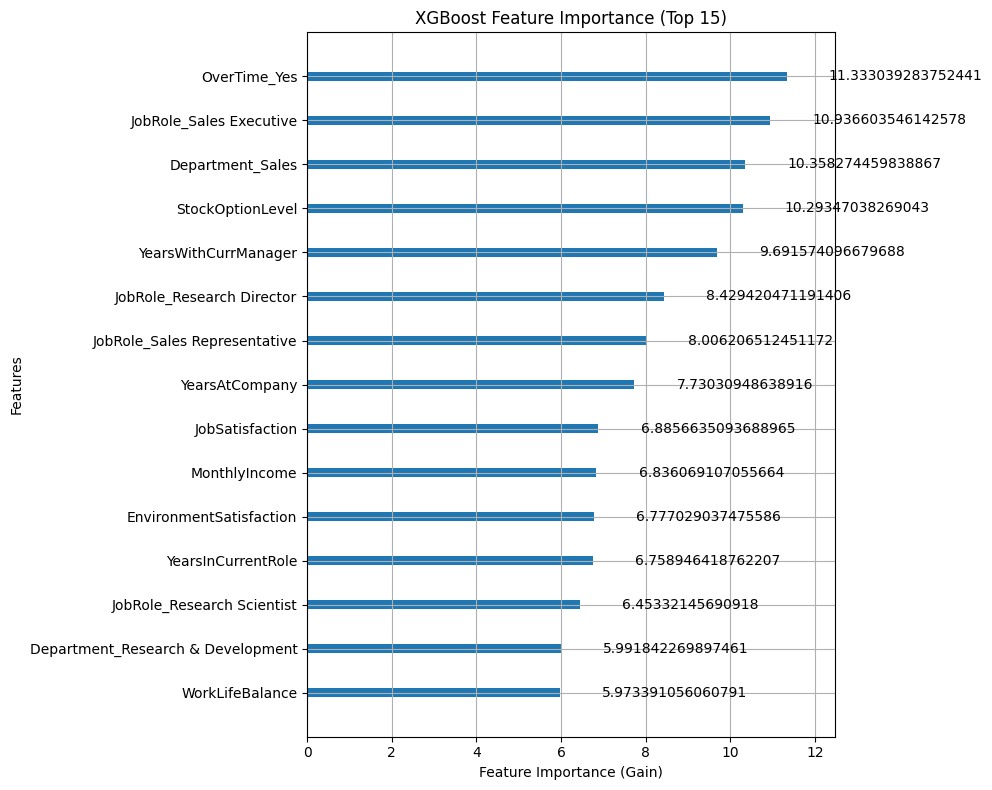

In [11]:
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
import xgboost as xgb

# Define numerical and categorical column names as used in get_hr_data
categorical_cols = ['BusinessTravel', 'Department','EducationField','Gender', 'JobRole', 'MaritalStatus', 'OverTime']
numerical_cols = ['Age', 'DailyRate', 'DistanceFromHome', 'Education','EnvironmentSatisfaction','HourlyRate','JobInvolvement','JobLevel','JobSatisfaction','MonthlyIncome', 'MonthlyRate', 'PercentSalaryHike', 'PerformanceRating', 'RelationshipSatisfaction', 'StockOptionLevel', 'TotalWorkingYears', 'TrainingTimesLastYear', 'WorkLifeBalance', 'YearsAtCompany', 'YearsInCurrentRole', 'YearsSinceLastPromotion', 'YearsWithCurrManager']

# Align with variable names used in the original cell's logic
num_cols = numerical_cols
cat_cols = categorical_cols

# Recreate the categorical transformer as used in get_hr_data for 'linear_xgb'
cat_transformer = OneHotEncoder(drop='first', handle_unknown='ignore', sparse_output=False)

# Recreate the preprocessor
reconstructed_preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), num_cols),
        ('cat', cat_transformer, cat_cols)
    ]
)

# Fit the preprocessor on X_clean (the full unprocessed DataFrame available in the kernel state)
# This is crucial for `named_transformers_` to be populated.
reconstructed_preprocessor.fit(X_clean)

# 1. ColumnTransformer에서 원-핫 인코딩된 범주형 특성 이름 추출
cat_encoder = reconstructed_preprocessor.named_transformers_['cat']
cat_feature_names = cat_encoder.get_feature_names_out(cat_cols)

# 2. 수치형 특성과 범주형 특성 이름 결합
feature_names = num_cols + cat_feature_names.tolist()

# 3. XGBoost 모델에 특성 이름 매핑
model_xgb.get_booster().feature_names = feature_names

# 4. 시각화 (상위 15개 변수)
fig, ax = plt.subplots(figsize=(10, 8))
xgb.plot_importance(
    model_xgb,
    max_num_features=15,
    importance_type='gain', # 정보 이득(Gain) 기준
    ax=ax,
    title='XGBoost Feature Importance (Top 15)',
    xlabel='Feature Importance (Gain)',
    ylabel='Features'
)
plt.tight_layout()
plt.show()

### [추가] 의사결정 나무(Decision Tree) 내부 구조 시각화 (원본 수치 기준)
사람이 직관적으로 이해하기 쉽도록, 수치형 변수를 스케일링하지 않은 원본 데이터로 가벼운 시각화용 모델을 만들어 첫 번째 트리(`num_trees=0`)의 판단 기준을 확인해 봅니다.

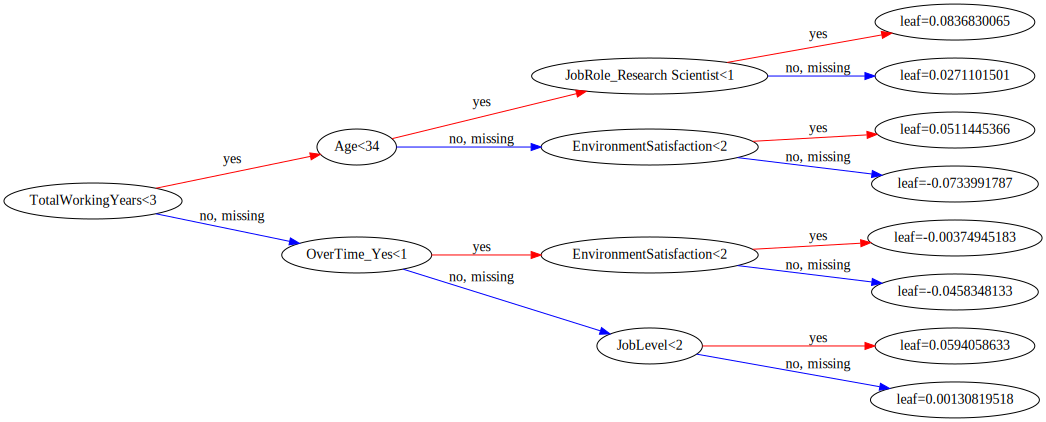

양수(+)로 클수록: 퇴사할 가능성(Yes)이 높다는 것을 의미
음수(-)로 작을수록: 퇴사하지 않고 유지할 가능성(No)이 높다는 것을 의미


In [12]:
import xgboost as xgb
import graphviz
from IPython.display import display
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.model_selection import train_test_split

# 1. 수치형 데이터는 스케일링하지 않고(passthrough), 범주형만 인코딩하는 시각화용 전처리기 생성
preprocessor_unscaled = ColumnTransformer(
    transformers=[
        ('num', 'passthrough', num_cols),
        ('cat', OneHotEncoder(handle_unknown='ignore', drop='first'), cat_cols)
    ]
)

# 2. 전처리 적용 및 데이터 분할
X_unscaled = preprocessor_unscaled.fit_transform(X_clean)
X_train_un, X_test_un, y_train_un, y_test_un = train_test_split(
    X_unscaled, y_clean, test_size=0.2, stratify=y_clean, random_state=42
)

# 3. 시각화용 모델 학습 (보기 편하게 깊이를 3으로 제한)
model_xgb_vis = xgb.XGBClassifier(
    objective='binary:logistic',
    max_depth=3,
    learning_rate=0.05,
    n_estimators=10, # 트리를 많이 만들 필요 없이 구조만 확인
    scale_pos_weight=pos_weight,
    random_state=42
)
model_xgb_vis.fit(X_train_un, y_train_un)

# 4. 피처 이름 매핑 (트리 노드에 변수명이 제대로 나오도록 설정)
cat_encoder_un = preprocessor_unscaled.named_transformers_['cat']
cat_feature_names_un = cat_encoder_un.get_feature_names_out(cat_cols)
feature_names_un = num_cols + cat_feature_names_un.tolist()
model_xgb_vis.get_booster().feature_names = feature_names_un

# 5. 첫 번째 트리 시각화
graph = xgb.to_graphviz(model_xgb_vis, tree_idx=0, rankdir='LR')
display(graph)
print("양수(+)로 클수록: 퇴사할 가능성(Yes)이 높다는 것을 의미\n음수(-)로 작을수록: 퇴사하지 않고 유지할 가능성(No)이 높다는 것을 의미")

# ==========================================
# 6. 하이퍼파라미터 튜닝 (GridSearchCV)
# ==========================================

In [13]:
from sklearn.model_selection import GridSearchCV
# 1. 탐색할 파라미터 조합 설정
param_grid = {
    'max_depth': [3, 4, 5],
    'learning_rate': [0.01, 0.05, 0.1],
    'n_estimators': [100, 200, 300]
}

# 2. GridSearchCV 객체 생성
# -> '퇴사할 사람을 잘 잡아내는 것'이 중요하므로 scoring='recall'로 설정
grid_search = GridSearchCV(
    estimator=xgb.XGBClassifier(
        objective='binary:logistic',
        scale_pos_weight=pos_weight, # 타겟 불균형 처리는 유지
        random_state=42
    ),
    param_grid=param_grid,
    scoring='recall',
    cv=3,      # 3겹 교차 검증
    n_jobs=-1, # 모든 CPU 코어 사용
    verbose=1
)

# 3. 튜닝 실행
grid_search.fit(X_train, y_train)

print("\n[최적의 하이퍼파라미터]")
print(grid_search.best_params_)

# 4. 찾은 최적의 모델로 재평가
best_xgb = grid_search.best_estimator_
y_pred_tuned = best_xgb.predict(X_test)

print("\n" + "="*40)
print(" 튜닝 후 XGBoost 평가 지표 (최적화 모델)")
print("="*40)
print(f"▶ 정확도 (Accuracy)  : {accuracy_score(y_test, y_pred_tuned):.4f}")
print(f"▶ 정밀도 (Precision) : {precision_score(y_test, y_pred_tuned):.4f}")
print(f"▶ 재현율 (Recall)    : {recall_score(y_test, y_pred_tuned):.4f}  <-- 변화 확인!")
print(f"▶ F1-Score         : {f1_score(y_test, y_pred_tuned):.4f}")
print("="*40)

Fitting 3 folds for each of 27 candidates, totalling 81 fits

[최적의 하이퍼파라미터]
{'learning_rate': 0.01, 'max_depth': 3, 'n_estimators': 200}

 튜닝 후 XGBoost 평가 지표 (최적화 모델)
▶ 정확도 (Accuracy)  : 0.7873
▶ 정밀도 (Precision) : 0.3778
▶ 재현율 (Recall)    : 0.4722  <-- 변화 확인!
▶ F1-Score         : 0.4198


# ==========================================
# 7. 추가 분석: 부서 및 직무별 퇴사율 시각화
# ==========================================

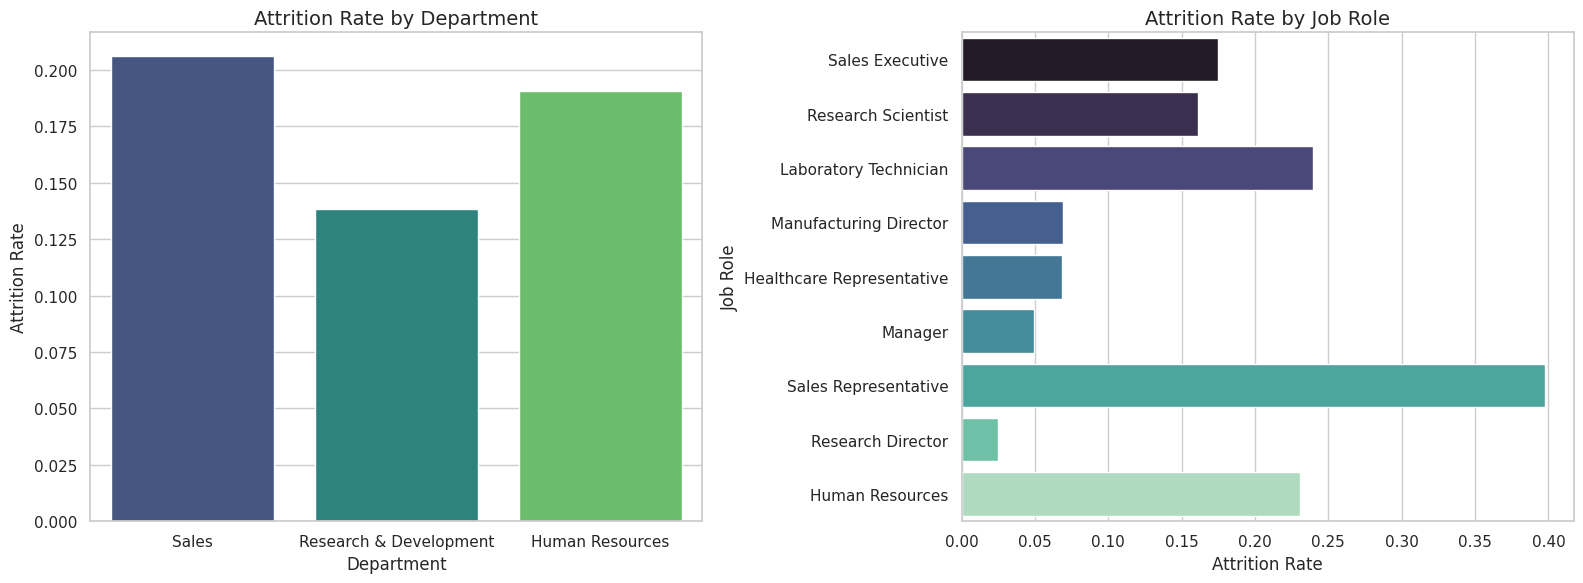

In [14]:
import seaborn as sns
import matplotlib.pyplot as plt

# 한글 폰트 경고를 방지하기 위해 영어 기본 폰트 사용 또는 스타일 설정
sns.set_theme(style="whitegrid")

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# 1. 부서별 퇴사율
# df_clean['Attrition']은 이미 0과 1로 변환되어 있으므로 평균을 구하면 퇴사율이 됩니다.
sns.barplot(x='Department', y='Attrition', data=df_clean, ax=axes[0], errorbar=None, palette='viridis', hue='Department', legend=False)
axes[0].set_title('Attrition Rate by Department', fontsize=14)
axes[0].set_ylabel('Attrition Rate')
axes[0].set_xlabel('Department')

# 2. 직무별(JobRole) 퇴사율 (수치가 많아 가로로 눕혀서 출력)
sns.barplot(y='JobRole', x='Attrition', data=df_clean, ax=axes[1], errorbar=None, palette='mako', hue='JobRole', legend=False)
axes[1].set_title('Attrition Rate by Job Role', fontsize=14)
axes[1].set_xlabel('Attrition Rate')
axes[1].set_ylabel('Job Role')

plt.tight_layout()
plt.show()